# EDA -Exploratory data analysis

In [ ]:
-In EDA, we understand we understand dataset before doing analysis
1.checking file format
2.understanding rows and column
3.handling the null values
4.handling the duplicate values
5.When data is clean then we can do analysis on it. checking data is in correct format/standard

---before making visualisation and analysis
1.univariant (single data - eg:- total_shares,total_products) 
2.bivariant (year vs sales, product vs sales)

# Importing modules

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Creating dataframe

In [2]:
try:
    df=pd.read_csv(R"C:\Users\Utkarsha\Downloads\delivery_orders_dataset.csv")
except FileNotFoundError:
    print("please check file path again")
else:
    print("file loaded successfully")

file loaded successfully


# Inspecting dataframe

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           3000 non-null   str    
 1   order_date         3000 non-null   str    
 2   order_placed_time  3000 non-null   str    
 3   day_of_week        3000 non-null   str    
 4   city               3000 non-null   str    
 5   vendor_id          3000 non-null   str    
 6   vendor_name        3000 non-null   str    
 7   order_type         3000 non-null   str    
 8   driver_id          3000 non-null   str    
 9   distance_km        3000 non-null   float64
 10  weather_condition  3000 non-null   str    
 11  is_peak_hour       3000 non-null   int64  
 12  order_value_inr    3000 non-null   float64
 13  delivery_time_min  2913 non-null   float64
 14  is_delayed         3000 non-null   int64  
 15  is_cancelled       3000 non-null   int64  
 16  customer_rating    2913 non-null   

## Changing datatype of order_date column

In [11]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           3000 non-null   str           
 1   order_date         3000 non-null   datetime64[us]
 2   order_placed_time  3000 non-null   str           
 3   day_of_week        3000 non-null   str           
 4   city               3000 non-null   str           
 5   vendor_id          3000 non-null   str           
 6   vendor_name        3000 non-null   str           
 7   order_type         3000 non-null   str           
 8   driver_id          3000 non-null   str           
 9   distance_km        3000 non-null   float64       
 10  weather_condition  3000 non-null   str           
 11  is_peak_hour       3000 non-null   int64         
 12  order_value_inr    3000 non-null   float64       
 13  delivery_time_min  2913 non-null   float64       
 14  is_delayed         

## show duplicate record if found any remove them

In [6]:
duplicate_found=df.duplicated().sum()
print("duplicate record found in dataset=",duplicate_found)

duplicate record found in dataset= 0


In [7]:
df.isnull().sum()

order_id              0
order_date            0
order_placed_time     0
day_of_week           0
city                  0
vendor_id             0
vendor_name           0
order_type            0
driver_id             0
distance_km           0
weather_condition     0
is_peak_hour          0
order_value_inr       0
delivery_time_min    87
is_delayed            0
is_cancelled          0
customer_rating      87
dtype: int64

In [8]:
avg_deli=df["delivery_time_min"].mean().round()
print(f"avg delivery minutes is {avg_deli}min.")
df["delivery_time_min"]=df["delivery_time_min"].fillna(avg_deli)

avg delivery minutes is 31.0min.


In [9]:
most_frequent_rating=df['customer_rating'].mode()[0]
df["customer_rating"]=df["customer_rating"].fillna(most_frequent_rating)
print(f"most frequent rating is {most_frequent_rating}")

most frequent rating is 4.0


# Univariant analysis

In [ ]:
-avg order price
-total vendors
-avg delivery time
-avg delivery distance
-most ordered vendor

In [11]:
df

,order_id,order_date,order_placed_time,day_of_week,city,vendor_id,vendor_name,order_type,driver_id,distance_km,weather_condition,is_peak_hour,order_value_inr,delivery_time_min,is_delayed,is_cancelled,customer_rating
0,ORD00001,2026-01-03,22:33:00,Saturday,Mumbai,V007,Wok This Way,Grocery,DRV008,2.35,Clear,0,164.02,27.5,0,0,4.0
1,ORD00002,2026-02-07,16:01:00,Saturday,Delhi,V006,Tandoori Nights,Food Delivery,DRV014,0.90,Clear,0,370.86,21.0,0,0,4.0
2,ORD00003,2026-04-08,16:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV001,0.66,Clear,0,374.36,16.1,0,0,5.0
3,ORD00004,2026-04-20,22:38:00,Monday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV037,4.71,Rain,0,1053.90,41.3,0,0,4.0
4,ORD00005,2026-03-10,22:50:00,Tuesday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV060,1.20,Clear,0,258.10,24.7,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ORD02996,2026-06-22,14:37:00,Monday,Bengaluru,V004,Curry Express,Food Delivery,DRV003,2.80,Clear,0,362.84,28.6,0,0,5.0
2996,ORD02997,2026-05-15,18:51:00,Friday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV049,5.07,Clear,0,501.35,36.1,0,0,4.0
2997,ORD02998,2026-02-05,14:28:00,Thursday,Bengaluru,V008,Pizza Junction,Food Delivery,DRV054,1.75,Clear,0,1272.07,26.1,0,0,5.0
2998,ORD02999,2026-04-22,15:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV055,2.47,Clear,0,339.92,17.9,0,0,5.0


### average order price

In [12]:
avg_order_price=df["order_value_inr"].mean().round()
print(f"avg order price is ${avg_order_price}.")
df["order_value_inr"]=df["order_value_inr"].fillna(avg_order_price)

avg order price is $763.0.


### total vendor names

In [13]:
vendor_names=df["vendor_name"].unique()
print(f"total vendors is ={len(vendor_names)}")
print(f"names of vendor={list(vendor_names)}")

total vendors is =12
names of vendor=['Wok This Way', 'Tandoori Nights', 'Urban Tadka', 'Spice Route Kitchen', 'Green Leaf Cafe', 'Curry Express', 'Bun Intended Burgers', 'Roti Roll Co.', 'Dosa Point', 'Bowl & Broth', 'Sushi Central', 'Pizza Junction']


### most ordered vendor

In [14]:
df.groupby("vendor_name")["vendor_id"].count().sort_values(ascending=False).reset_index()

,vendor_name,vendor_id
0,Wok This Way,277
1,Urban Tadka,273
2,Bun Intended Burgers,270
3,Roti Roll Co.,262
4,Pizza Junction,255
5,Curry Express,254
6,Green Leaf Cafe,249
7,Sushi Central,247
8,Bowl & Broth,245
9,Tandoori Nights,226


In [15]:
most_ordered=df["vendor_name"].mode()[0]
print(f"most ordered place is : {most_ordered}")

most ordered place is : Wok This Way


### avg delivery time


In [16]:
avg_deli=df["delivery_time_min"].mean().round()
print(f"avg delivery time is : {avg_deli}min.")
df["delivery_time_min"]=df["delivery_time_min"].fillna(avg_deli)

avg delivery time is : 31.0min.


### avg delivery distance

In [17]:
avg_deli_distance=df["distance_km"].mean().round()
print(f"avg delivery distance {avg_deli_distance}km")
df["distance_km"]=df["distance_km"].fillna(avg_deli_distance)

avg delivery distance 3.0km


### most ordered weekday

In [49]:
df.groupby("day_of_week")["order_id"].count().sort_values(ascending=False)

day_of_week
Saturday     456
Friday       452
Tuesday      429
Sunday       427
Monday       426
Thursday     426
Wednesday    384
Name: order_id, dtype: int64

In [71]:
most_ordered_weekday=df["day_of_week"].mode()[0]
print(f"most ordered weekday is : {most_ordered_weekday}")

most ordered weekday is : Saturday


### show delayed and cancelled ratio

In [90]:
#cancelled orders
cancelled_orders=df[df["is_cancelled"]==1]
cc=cancelled_orders["order_id"].count()
print(f"total cancelled order ratio is =  {cc/3000*100}%")

total cancelled order ratio is =  2.9000000000000004%


In [89]:
#delayed orders
delay_orders=df[df['is_delayed']==1]
dc=delay_orders["order_id"].count()
print(f"total delay order ratio is =  {dc/3000*100}%")

total delay order ratio is =  13.0%


# . Bivariant analysis

In [63]:
df["weather_condition"].unique()

<StringArray>
['Clear', 'Rain', 'Heavy Traffic Event']
Length: 3, dtype: str

In [64]:
df["is_delayed"]=df["is_delayed"].replace(0,"No").replace(1,"Yes")
df["is_cancelled"]=df["is_cancelled"].replace(0,"No").replace(1,"Yes")

In [65]:
df.groupby(["weather_condition",'is_delayed',"is_cancelled"])["order_id"].count().reset_index()

,weather_condition,is_delayed,is_cancelled,order_id
0,Clear,No,No,1946
1,Clear,No,Yes,73
2,Clear,Yes,No,242
3,Heavy Traffic Event,No,No,144
4,Heavy Traffic Event,No,Yes,6
5,Heavy Traffic Event,Yes,No,67
6,Rain,No,No,433
7,Rain,No,Yes,8
8,Rain,Yes,No,81


# sorting data in form of categories

In [66]:
def delivery_time_category(time):
    if time>=31:
        return "Late"
    elif time>=16:
        return "on time"
    else:
        return "fast"

In [67]:
delivery_time_category(9)

'fast'

In [68]:
df["delivery_time_remarks"]=df["delivery_time_min"].map(delivery_time_category)

In [69]:
df

,order_id,order_date,order_placed_time,day_of_week,city,vendor_id,vendor_name,order_type,driver_id,distance_km,...,is_peak_hour,order_value_inr,delivery_time_min,is_delayed,is_cancelled,customer_rating,month,delivery_time_remarks,delivery_distance,day
0,ORD00001,2026-01-03,22:33:00,Saturday,Mumbai,V007,Wok This Way,Grocery,DRV008,2.35,...,0,164.02,27.5,No,No,4.0,1,on time,short distance,2026-01-03
1,ORD00002,2026-02-07,16:01:00,Saturday,Delhi,V006,Tandoori Nights,Food Delivery,DRV014,0.90,...,0,370.86,21.0,No,No,4.0,2,on time,short distance,2026-02-07
2,ORD00003,2026-04-08,16:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV001,0.66,...,0,374.36,16.1,No,No,5.0,4,on time,short distance,2026-04-08
3,ORD00004,2026-04-20,22:38:00,Monday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV037,4.71,...,0,1053.90,41.3,No,No,4.0,4,Late,short distance,2026-04-20
4,ORD00005,2026-03-10,22:50:00,Tuesday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV060,1.20,...,0,258.10,24.7,No,No,4.0,3,on time,short distance,2026-03-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ORD02996,2026-06-22,14:37:00,Monday,Bengaluru,V004,Curry Express,Food Delivery,DRV003,2.80,...,0,362.84,28.6,No,No,5.0,6,on time,short distance,2026-06-22
2996,ORD02997,2026-05-15,18:51:00,Friday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV049,5.07,...,0,501.35,36.1,No,No,4.0,5,Late,medium distance,2026-05-15
2997,ORD02998,2026-02-05,14:28:00,Thursday,Bengaluru,V008,Pizza Junction,Food Delivery,DRV054,1.75,...,0,1272.07,26.1,No,No,5.0,2,on time,short distance,2026-02-05
2998,ORD02999,2026-04-22,15:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV055,2.47,...,0,339.92,17.9,No,No,5.0,4,on time,short distance,2026-04-22


In [27]:
df.groupby("delivery_time_remarks")["order_id"].count().reset_index()

,delivery_time_remarks,order_id
0,Late,1226
1,fast,270
2,on time,1504


In [28]:
df

,order_id,order_date,order_placed_time,day_of_week,city,vendor_id,vendor_name,order_type,driver_id,distance_km,weather_condition,is_peak_hour,order_value_inr,delivery_time_min,is_delayed,is_cancelled,customer_rating,month,delivery_time_remarks
0,ORD00001,2026-01-03,22:33:00,Saturday,Mumbai,V007,Wok This Way,Grocery,DRV008,2.35,Clear,0,164.02,27.5,0,0,4.0,1,on time
1,ORD00002,2026-02-07,16:01:00,Saturday,Delhi,V006,Tandoori Nights,Food Delivery,DRV014,0.90,Clear,0,370.86,21.0,0,0,4.0,2,on time
2,ORD00003,2026-04-08,16:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV001,0.66,Clear,0,374.36,16.1,0,0,5.0,4,on time
3,ORD00004,2026-04-20,22:38:00,Monday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV037,4.71,Rain,0,1053.90,41.3,0,0,4.0,4,Late
4,ORD00005,2026-03-10,22:50:00,Tuesday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV060,1.20,Clear,0,258.10,24.7,0,0,4.0,3,on time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ORD02996,2026-06-22,14:37:00,Monday,Bengaluru,V004,Curry Express,Food Delivery,DRV003,2.80,Clear,0,362.84,28.6,0,0,5.0,6,on time
2996,ORD02997,2026-05-15,18:51:00,Friday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV049,5.07,Clear,0,501.35,36.1,0,0,4.0,5,Late
2997,ORD02998,2026-02-05,14:28:00,Thursday,Bengaluru,V008,Pizza Junction,Food Delivery,DRV054,1.75,Clear,0,1272.07,26.1,0,0,5.0,2,on time
2998,ORD02999,2026-04-22,15:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV055,2.47,Clear,0,339.92,17.9,0,0,5.0,4,on time


In [29]:
df['distance_km'].max()

np.float64(14.85)

In [30]:
df['distance_km'].min()

np.float64(0.05)

In [31]:
def delivery_distance_cat(distance):
    if distance>=10:
        return "Long distance"
    elif distance>=5:
        return "medium distance"
    else:
        return "short distance"

In [32]:
delivery_distance_cat(10)

'Long distance'

In [33]:
df["delivery_distance"]=df["distance_km"].map(delivery_distance_cat)

In [34]:
df

,order_id,order_date,order_placed_time,day_of_week,city,vendor_id,vendor_name,order_type,driver_id,distance_km,weather_condition,is_peak_hour,order_value_inr,delivery_time_min,is_delayed,is_cancelled,customer_rating,month,delivery_time_remarks,delivery_distance
0,ORD00001,2026-01-03,22:33:00,Saturday,Mumbai,V007,Wok This Way,Grocery,DRV008,2.35,Clear,0,164.02,27.5,0,0,4.0,1,on time,short distance
1,ORD00002,2026-02-07,16:01:00,Saturday,Delhi,V006,Tandoori Nights,Food Delivery,DRV014,0.90,Clear,0,370.86,21.0,0,0,4.0,2,on time,short distance
2,ORD00003,2026-04-08,16:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV001,0.66,Clear,0,374.36,16.1,0,0,5.0,4,on time,short distance
3,ORD00004,2026-04-20,22:38:00,Monday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV037,4.71,Rain,0,1053.90,41.3,0,0,4.0,4,Late,short distance
4,ORD00005,2026-03-10,22:50:00,Tuesday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV060,1.20,Clear,0,258.10,24.7,0,0,4.0,3,on time,short distance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ORD02996,2026-06-22,14:37:00,Monday,Bengaluru,V004,Curry Express,Food Delivery,DRV003,2.80,Clear,0,362.84,28.6,0,0,5.0,6,on time,short distance
2996,ORD02997,2026-05-15,18:51:00,Friday,Chennai,V001,Spice Route Kitchen,Food Delivery,DRV049,5.07,Clear,0,501.35,36.1,0,0,4.0,5,Late,medium distance
2997,ORD02998,2026-02-05,14:28:00,Thursday,Bengaluru,V008,Pizza Junction,Food Delivery,DRV054,1.75,Clear,0,1272.07,26.1,0,0,5.0,2,on time,short distance
2998,ORD02999,2026-04-22,15:56:00,Wednesday,Chennai,V002,Urban Tadka,Food Delivery,DRV055,2.47,Clear,0,339.92,17.9,0,0,5.0,4,on time,short distance


# Visualisation

## Bar chart

### vendor name by order count

In [48]:
vendor_name=df.groupby("vendor_name")["order_id"].count().sort_values(ascending=False).reset_index()

<function matplotlib.pyplot.show(close=None, block=None)>

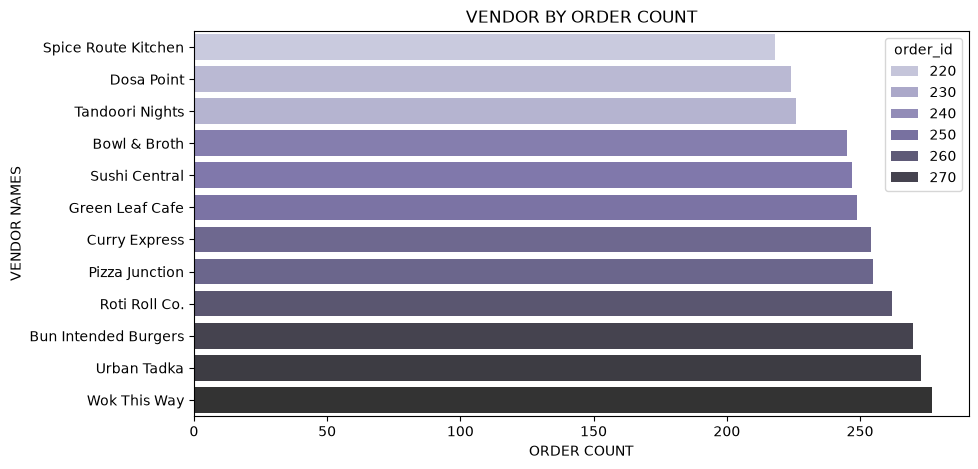

In [49]:
vendor_orders=df.groupby("vendor_name")["order_id"].count().sort_values().reset_index()
plt.figure(figsize=(10,5))
plt.title("VENDOR BY ORDER COUNT")
plt.ylabel("VENDOR NAMES")
plt.xlabel("ORDER COUNT")
sns.barplot(x="order_id",y="vendor_name",data=vendor_orders,palette='Purples_d',hue="order_id")
plt.show

### weekday by order count

<function matplotlib.pyplot.show(close=None, block=None)>

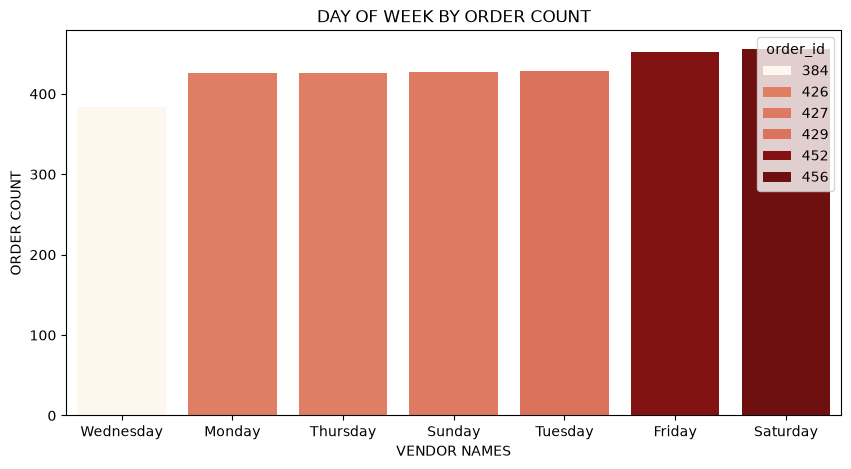

In [50]:
weekday_orders=df.groupby("day_of_week")["order_id"].count().sort_values().reset_index()
plt.figure(figsize=(10,5))
plt.title("DAY OF WEEK BY ORDER COUNT")
plt.xlabel("VENDOR NAMES")
plt.ylabel("ORDER COUNT")
sns.barplot(y="order_id",x="day_of_week",data=weekday_orders,palette='OrRd',hue="order_id")
plt.show

## Pie chart

In [ ]:
-for ratio in percentage and less than 4 property

### order type ratio

In [52]:
df["order_type"].unique()

<StringArray>
['Grocery', 'Food Delivery', 'Pharmacy']
Length: 3, dtype: str

In [53]:
order_type_ratio=df.groupby("order_type")["order_id"].count()
order_type_ratio

order_type
Food Delivery    2163
Grocery           608
Pharmacy          229
Name: order_id, dtype: int64

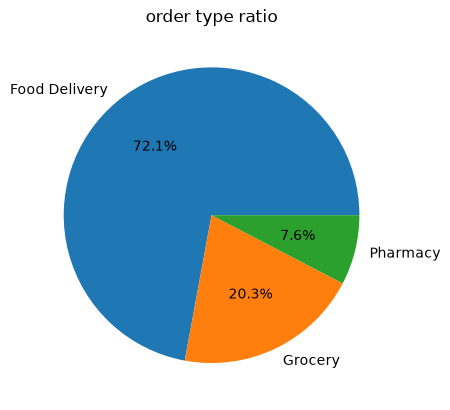

In [54]:
order_type_ratio.plot(kind="pie",autopct="%1.1f%%")
plt.title("order type ratio")
plt.show()

## scatter plot

### delivery vs distance

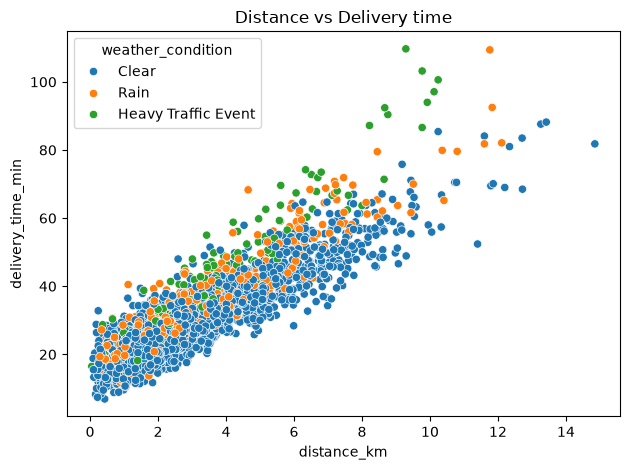

In [55]:
sns.scatterplot(x="distance_km" , y="delivery_time_min", data=df ,hue ="weather_condition")
plt.title("Distance vs Delivery time")
plt.tight_layout() #it make layout as per saving parameters
plt.savefig("distance_delivery.png")
plt.show()

In [56]:
df["month"]=df["order_date"].dt.month

## Line plot

### Month vs revenue

<function matplotlib.pyplot.show(close=None, block=None)>

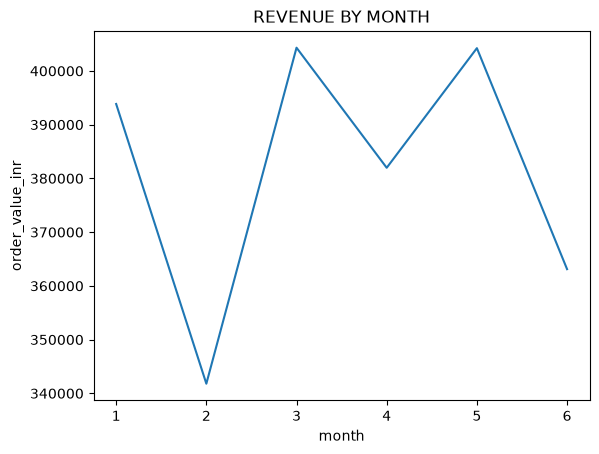

In [57]:
month_revenue=df.groupby("month")["order_value_inr"].sum().reset_index()
sns.lineplot(x="month",y="order_value_inr",data=month_revenue)
plt.title("REVENUE BY MONTH")
plt.show

## Histplot

<function matplotlib.pyplot.show(close=None, block=None)>

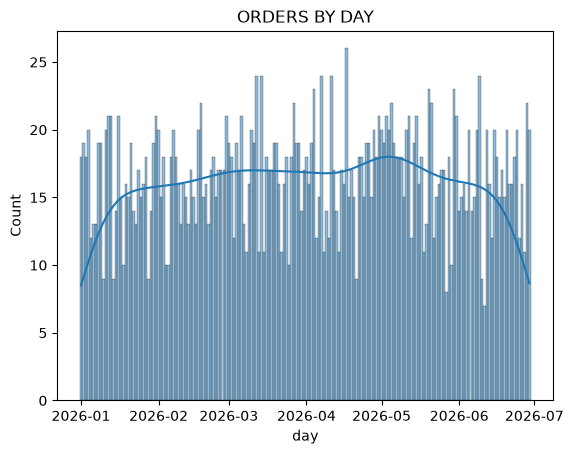

In [62]:
df["day"]=df["order_date"].dt.date
sns.histplot(data=df ,x="day",kde=True)
plt.title("ORDERS BY DAY")
plt.show